# TCC do Google Data Analytics
### Estudo de caso: Como uma empresa de bem-estar pode ser inteligente?

### Visão Geral


| | |
|----|-----|
| **Analista de dados** | Ana Letícia Cabral do Rosário |
| **Partes interessadas** | Equipe executiva da Bellabeat, empresa responsável pela fabricação de tecnologias que monitoram a saúde feminina. |
| **Problema a resolver** | Identificar o comportamento dos consumidores de dispositivos inteligentes e como posso transformar essas informações em uma **estratégia de marketing** para um produto específico da Bellabeat. |


---

### Cenário

> "Você é um analista de dados júnior na equipe de **análise de marketing da Bellabeat**, uma fabricante de alta tecnologia de produtos inteligentes voltados para a saúde feminina. A Bellabeat é uma empresa pequena de sucesso, mas tem potencial para se tornar um player mais relevante no mercado global de dispositivos inteligentes. Urška Sršen, cofundadora e Diretora de Criação da Bellabeat, acredita que a análise de dados de fitness de dispositivos inteligentes pode ajudar a abrir novas oportunidades de crescimento para a empresa. **Você foi solicitado a focar em um dos produtos da Bellabeat e analisar dados de dispositivos inteligentes para entender como os consumidores estão usando esses dispositivos**. **Os insights que você descobrir ajudarão a orientar a estratégia de marketing da empresa**. Você apresentará sua análise à equipe executiva da Bellabeat junto com recomendações de alto nível para a estratégia de marketing."

#### Produtos da Bellabeat

- **Aplicativo Bellabeat:** O aplicativo Bellabeat fornece aos usuários dados de saúde relacionados à atividade física, sono, estresse, ciclo menstrual e hábitos de mindfulness. Esses dados podem ajudar os usuários a entender melhor seus hábitos atuais e tomar decisões mais saudáveis. O aplicativo Bellabeat se conecta à linha de produtos inteligentes de bem-estar da empresa.

- **Leaf:** O rastreador de bem-estar clássico da Bellabeat pode ser usado como pulseira, colar ou presilha. O Leaf se conecta ao aplicativo Bellabeat para monitorar atividade física, sono e estresse.

- **Time:** Este relógio de bem-estar combina a aparência atemporal de um relógio clássico com tecnologia inteligente para monitorar atividade física, sono e estresse. O relógio Time se conecta ao aplicativo Bellabeat para fornecer insights sobre o bem-estar diário.


- **Spring:** Esta é uma garrafa de água que rastreia a ingestão diária de água usando tecnologia inteligente para garantir que você esteja adequadamente hidratado ao longo do dia. A garrafa Spring se conecta ao aplicativo Bellabeat para monitorar seus níveis de hidratação.

- **Assinatura Bellabeat:** A Bellabeat também oferece um programa de assinatura para seus usuários. A assinatura oferece acesso 24/7 a orientações totalmente personalizadas sobre nutrição, atividade física, sono, saúde, beleza e mindfulness com base no estilo de vida e nos objetivos de cada usuário.

---
### Perguntas de Negócio

1. Quais são algumas tendências no uso de dispositivos inteligentes?
2. Como essas tendências podem se aplicar aos clientes da Bellabeat?
3. Como essas tendências podem ajudar a influenciar a **estratégia de marketing** da Bellabeat?




### Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns

sns.set_theme(style = 'whitegrid')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

### DataFrames

In [ ]:
# Métrica coletada no primeiro período
marco_abril_2016 =  'dailyActivity_1'      # 1 - Atividade diária dos usuários (Março/Abril)

# Métricas coletadas no segundo período
abril_maio_2016 = ['dailyActivity',        # 2 - Atividade diária dos usuários (Abril/Maio)
                   'sleepDay']             # 3 - Sono diário dos usuários

todos_arquivos = {}

todos_arquivos[marco_abril_2016] = pd.read_csv(f"/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv", low_memory = False)

for arquivo in abril_maio_2016:
    todos_arquivos[f'{arquivo}_2'] = pd.read_csv(f"/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/{arquivo}_merged.csv", low_memory = False)


### Funções para gráficos

In [ ]:
# Função para gerar um gráfico de barras que permite visualizar a média de diferentes métricas ao longo dos períodos
def plot_bar_tendencia(data, x, y, color, suptitle, title, ylabel, xlabel):

    # Configuração do gráfico de barras

    data['dia_mes'] = data[x].dt.strftime('%d/%m') # formato dia/mes

    plt.figure(figsize = (15,5))

    ax = sns.barplot(data = data, x = 'dia_mes', y = y, color = color)
    ax.bar_label(ax.containers[0], fontsize = 7, fmt = '%.0f') # Organiza o grupo de barras dentro de uma lista

    plt.suptitle(suptitle, fontsize = 14)
    plt.title(title, fontsize = 10)
    plt.ylabel(ylabel, fontsize = 9)
    plt.xlabel(xlabel, fontsize = 9)
    plt.xticks(rotation = 45, fontsize = 9)

    # Configuração da linha de tendência
    data['dia_num'] = range(len(data))
    z = np.polyfit(data['dia_num'], data[y], 1)
    p = np.poly1d(z)

    plt.plot(
    data['dia_num'],
    p(data['dia_num']),
    color = 'tomato',
    linestyle = '-',
    linewidth = 2,
    label = 'Tendência',
    )
    plt.legend()
    plt.tight_layout()
    return plt.show()

In [ ]:
# Função que gera um Histograma e descrição de seus dados
def histograma(dados, title, ylabel, xlabel):

    plt.figure(figsize = (15,5))


    if (
        dados is todos_arquivos['dailyActivity_1']['VeryActiveMinutes'] or
        dados is todos_arquivos['dailyActivity_1']['FairlyActiveMinutes'] or
        dados is todos_arquivos['dailyActivity_1']['LightlyActiveMinutes'] or
        dados is todos_arquivos['dailyActivity_2']['VeryActiveMinutes'] or
        dados is todos_arquivos['dailyActivity_2']['FairlyActiveMinutes'] or
        dados is todos_arquivos['dailyActivity_2']['LightlyActiveMinutes']
        ):
        limite = range(0, 731, 30)

    elif dados is todos_arquivos['sleepDay_2']:
        limite = range(0, 801, 60)
    else:
        limite = range(0, 1501, 60)


    ax = sns.histplot(dados, bins = limite, kde = True) # Linha de densidade suave

    ax.bar_label(ax.containers[0], fontsize = 9, fmt = '%.0f')

    plt.title(title)
    plt.ylabel(ylabel, fontsize = 10)
    plt.xlabel(xlabel, fontsize = 10)
    plt.xticks(limite, fontsize = 8, rotation = 45)
    plt.show()

    display(dados.describe())

In [ ]:
# Função para gerar um gráfico de dispersão
def dispersao(data, x, y, suptitle, title, ylabel, xlabel):

    plt.figure(figsize = (10, 8))

    sns.scatterplot(data = data, x = x, y = y, color = '#507696')


    # Configuração da linha de tendência
    z = np.polyfit(data[x], data[y],1)
    p = np.poly1d(z)

    plt.plot(
       data[x],
       p(data[x]),
       color = 'tomato',
       linestyle = '-',
       linewidth = 2,
       label = 'Correlação'
    )
    plt.legend()


    plt.suptitle(suptitle, fontsize = 14)
    plt.title(title, fontsize = 10)
    plt.ylabel(ylabel, fontsize = 9)
    plt.xlabel(xlabel, fontsize = 9)
    plt.tight_layout()
    plt.show()

    print(f'Índice de correlação: {data[x].corr(data[y])}')

## 1. Primeira análise: Compreensão dos dados

🎲 O objetivo desta seção é compreender a estrutura e a qualidade dos dados obtidos.

<br>

**1. Armazenamento dos dados:** Comunidade de Cientistas de dados [Kaggle](https://www.kaggle.com/datasets/arashnic/fitbit).

---

**2. Organização dos dados:**

- 29 arquivos no formato CSV;
  
- Registros coletados entre **março e maio de 2016** de usuários da tecnologia Fitbit (dispositivo de monitoramento de atividades físicas capaz de registrar métricas como qualidade do sono, peso, calorias queimadas, entre outras);

  
- No total, 35 usuários consentiram com o compartilhamento de seus dados de forma anônima, sendo cada participante identificado exclusivamente por meio do campo Id.

- Para o desenvolvimento deste projeto, foram selecionados 3 dos 29 arquivos disponíveis, todos contendo registros diários dos participantes:

  1. dailyActivity_merged (março/abril);
  2. dailyActivity_merged (abril/maio);
  3. sleepDay_merged (abril/maio).

___

**3. Problemas identificados**:

- Os dados provêm de uma fonte pública reconhecida, a comunidade Kaggle, porém foram originalmente coletados por meio de uma pesquisa distribuída via Amazon Mechanical Turk, conforme indicado pelo criador do dataset, o que os classifica como **dados de terceiros**.

- Os dados não categorizam os usuários que são do sexo feminino ou do masculino. Para atender a proposta da Bellabeat, seria importante que tivesse essa distinção.

- Além disso, a **amostra é reduzida** (apenas 35 participantes) e nem todos responderam a todas as métricas, o que limita a representatividade dos resultados.

- Os dados também são de 2016, portanto estão **desatualizados**.

<br>
<br>

> Diante desse cenário, não é possível afirmar com plena segurança que os dados são totalmente confiáveis. Por isso, é fundamental manter uma postura crítica ao longo de toda a análise, a fim de evitar conclusões enviesadas. Além disso, é importante ter em mente que os insights obtidos estão condicionados ao contexto e às limitações desses dados.
>
> No entanto, dado o caráter educacional desta análise, um estudo de caso da Certificação de Análise de Dados do Google, com cenário fictício e dataset fornecido pelo próprio Google, essas limitações são reconhecidas e consideradas, mas não impedem a extração de insights relevantes para o objetivo proposto: Identificar o comportamento dos consumidores de dispositivos inteligentes e como posso transformar essas informações em uma **estratégia de marketing** para um produto específico da Bellabeat.

<br>
<br>

___

**4. Licenciamento, privacidade, segurança e acessibilidade:**

- Os dados são de acesso público e estão disponíveis sob licença aberta no Kaggle.

- As análises foram conduzidas com foco em clareza e organização, documentando cada etapa de forma transparente.

___

**5. Integridade dos dados:**

- A integridade foi verificada com a biblioteca Pandas do Python, inspecionando valores nulos, registros duplicados e tipos de dados.

- De modo geral, os dados estão em boas condições, com apenas algumas inconsistências pontuais a serem tratadas.

---
**6. Características dos dados a serem analisados:**

<br>

| Características | Descrição |
|---|---|
| **Participantes** | Quantas pessoas forneceram seus dados para cada métrica realizada |
| **Colunas** | Nome das colunas |
| **Dimensões** | Quantidade de linhas e colunas |
| **Duplicatas** | Quantidade de duplicatas |
| **Memória** | O quanto da memória está sendo consumido |
| **Tipos dos dados** | Tipo dos dados para cada coluna |
| **Nulos**| Quantidade de valores nulos por coluna

<br>
<br>
<br>
<br>

| # | Conclusão |
|---|---|
| 1 | No total, 35 usuários únicos forneceram dados de rastreamento de suas condições físicas. |
| 2 | Nem todas as métricas contam com a participação dos 35 usuários. |
| 3 | Colunas que contêm data estão sendo tratadas como object, sendo necessário convertê-las para o tipo datetime. |
| 4 | Não foram encontrados valores nulos. |
| 5 | O arquivo CSV sleepDay_merged possui 3 registros duplicados, sendo necessário realizar o tratamento de remoção dessas duplicatas antes das análises. |
| 6 | O arquivo CSV com menor número de participantes foi o sleepDay_merged, constando apenas 24 participantes. |

<br>

In [ ]:
# Código que analisa essas características:

todos_ids = pd.concat([df['Id'] for df in todos_arquivos.values()])

print(f'Total de participantes únicos: {todos_ids.nunique()}\n')
display(todos_ids.unique())

print('\n' + '='*50 + '\n')

for nome_df, df in todos_arquivos.items():

    print(f'→ DataFrame: {nome_df}\n')

    # Participantes
    participantes = df['Id'].nunique()
    print(f'→ Participantes únicos: {participantes}')

    # Estrutura
    print(f'\n→ Colunas:')
    display(df.columns)

    linhas, colunas = df.shape
    print(f'\n→ Dimensão: {linhas} linhas x {colunas} colunas')

    # Qualidade dos dados
    duplicatas = df.duplicated().sum()
    print(f'→ Duplicatas: {duplicatas}')

    memoria = df.memory_usage(deep=True).sum() / 1024**2
    print(f'→ Uso de memória: {memoria:.2f} MB')

    print(f'\n→ Tipos de dados:')
    display(df.dtypes)

    print(f'\n→ Valores nulos por coluna:')
    display(df.isnull().sum())

    # Amostra
    print(f'\n→ Amostra dos dados:')
    display(df.head())

    print('\n' + '-'*50 + '\n')

Total de participantes únicos: 35



array([1503960366, 1624580081, 1644430081, 1844505072, 1927972279,
       2022484408, 2026352035, 2320127002, 2347167796, 2873212765,
       2891001357, 3372868164, 3977333714, 4020332650, 4057192912,
       4319703577, 4388161847, 4445114986, 4558609924, 4702921684,
       5553957443, 5577150313, 6117666160, 6290855005, 6391747486,
       6775888955, 6962181067, 7007744171, 7086361926, 8053475328,
       8253242879, 8378563200, 8583815059, 8792009665, 8877689391])



→ DataFrame: dailyActivity_1

→ Participantes únicos: 35

→ Colunas:


Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')


→ Dimensão: 457 linhas x 15 colunas
→ Duplicatas: 0
→ Uso de memória: 0.07 MB

→ Tipos de dados:


...


→ Valores nulos por coluna:


Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


→ Amostra dos dados:


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712



--------------------------------------------------



## 2. Tratamento dos dados
🎲 O objetivo desta seção é garantir a integridade dos dados

### 2.1 Tipagem dos dados

In [ ]:
# Verificando o formato das colunas com datas

colunas_data = ['ActivityDate', 'SleepDay']

for chave, df in todos_arquivos.items():
    for coluna in colunas_data:
        if coluna in df.columns:
            print(f"{chave} -> {coluna}: {df[coluna].iloc[0]}")

dailyActivity_1 -> ActivityDate: 3/25/2016
dailyActivity_2 -> ActivityDate: 4/12/2016
sleepDay_2 -> SleepDay: 4/12/2016 12:00:00 AM


In [ ]:
# Alterando a tipagem dos dados de data para datetime

for chave, df in todos_arquivos.items():
    if 'ActivityDate' in df.columns:
        todos_arquivos[chave]['ActivityDate'] = pd.to_datetime(df['ActivityDate'], format='%m/%d/%Y')
    elif 'SleepDay' in df.columns:
        todos_arquivos[chave]['SleepDay'] = pd.to_datetime(df['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

In [ ]:
# Verificando novamente o formato das colunas com datas

colunas_data = ['ActivityDate', 'SleepDay']

for chave, df in todos_arquivos.items():
    for coluna in colunas_data:
        if coluna in df.columns:
            print(f"{chave} -> {coluna}: {df[coluna].iloc[0]}")

dailyActivity_1 -> ActivityDate: 2016-03-25 00:00:00
dailyActivity_2 -> ActivityDate: 2016-04-12 00:00:00
sleepDay_2 -> SleepDay: 2016-04-12 00:00:00


### 2.2 Duplicatas

In [ ]:
# Valores duplicados
print(todos_arquivos['sleepDay_2'].duplicated().sum())

display(todos_arquivos['sleepDay_2'][todos_arquivos['sleepDay_2'].duplicated(keep = False)])

3


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
160,4388161847,2016-05-05,1,471,495
161,4388161847,2016-05-05,1,471,495
222,4702921684,2016-05-07,1,520,543
223,4702921684,2016-05-07,1,520,543
379,8378563200,2016-04-25,1,388,402
380,8378563200,2016-04-25,1,388,402


In [ ]:
# Removendo duplicatas
todos_arquivos['sleepDay_2'] = todos_arquivos['sleepDay_2'].drop_duplicates().reset_index(drop = True)


# Para verificar se deu tudo certo
print(todos_arquivos['sleepDay_2'].duplicated().sum())
display(todos_arquivos['sleepDay_2'][todos_arquivos['sleepDay_2'].duplicated(keep = False)])

0


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed


## 3. Análise exploratória dos dados

O objetivo desta seção é realizar uma análise aprofundada dos dados diários dos usuários. Como os dados envolvem múltiplos participantes ao longo de diferentes períodos, as métricas serão calculadas com base em médias, garantindo uma representação mais fiel do comportamento coletivo.

A partir dessas médias, busca-se identificar padrões de comportamento, avaliar tendências ao longo do tempo, sejam elas estáveis, positivas ou negativas, e, com base no contexto dos dados, extrair as descobertas mais relevantes.

### 3.1 Atividade diária dos usuários:

["De acordo com a OMS, um indivíduo precisaria andar por pelo menos 30 minutos por dia; e totalizar no mínimo entre 150 a 201 minutos de caminhada por semana, como adianta Tania Szejnfeld Mann, ortopedista e traumatologista especializada em tornozelo, pé e doenças do osso."](https://www.nationalgeographicbrasil.com/ciencia/2024/02/quantos-passos-uma-pessoa-precisa-dar-por-dia)


Nesta seção, é apresentada uma análise dos padrões de **atividade física** dos participantes com base nos dados registrados por dispositivos inteligentes, abrangendo:

- **Média de passos registrados por cada dia e por usuário**;
- **Média do tempo de sedentarismo registrado por cada dia e por usuário** (em minutos)


#### 3.1.1 **(Março/Abril) de 2016**:

💡 **Descobertas relevantes**


- Os dados apresentaram incompletude ao longo do período analisado, uma vez que nem todos os usuários registraram suas informações diariamente. Observou-se grande variação na quantidade de participantes por dia, com registros que variaram entre apenas 2 usuários em algumas datas até 10 ou mais em outras.
  
- Do total dos 30 dias analisados, somente em 4 datas houve participação completa, com todos os 35 usuários fornecendo seus dados.

- **Ponto de decisão**: com base nesta situação, realizei duas análises:

1) Análise geral: apesar da presença de dados ausentes em parte do período, serão realizados cálculos considerando toda a base disponível.
   
2) Análise específica: serão considerados apenas os cálculos referentes às 4 datas em que houve participação completa dos 35 usuários. O objetivo é compreender o comportamento dos participantes em um recorte temporal mais controlado e com maior consistência dos dados.


---

✔️ **CONCLUSÃO**:

- Os usuários registrados apresentam uma média entre 6.538 a 7.009 passos diários. Apesar de nem todos terem fornecido dados ao longo dos 30 dias consecutivos, a diferença entre a média geral do período completo (com participação variável) e a média dos 4 dias (com presença integral) é pequena, de apenas 471 passos diários.

Isso confere a análise específica credibilidade e compatibilidade em seus resultados, indicando que a variação na quantidade de participantes não distorceu significamente os dados.

Portanto, é importante ressaltar que nos gráficos abordados (o mesmo vale pra sedentarismo) há discrepâncias das médias diárias devido a divergência da quantidade de usuários.

- Os usuários registrados apresentam uma média entre 989 e 1.010 minutos de sedentarismo por dia, o que equivale aproximadamente 16 a 17 horas ao dia. Assim como observado nos dados de passos, a diferença entre a média dos 30 dias e dos 4 dias é mínima (apenas 21 minutos).

Os resultados indicam que, em média, esses usuários passam mais da metade do dia em estado sedentário, o que representa um fator preocupante do ponto de vista da saúde.


##### 🔎 **Métricas/Cálculos**

1. Quantidade de registros por data;
2. Filtro dos registros com as datas nas quais todos os participantes forneceram seus dados;
3. Média de passos (geral e diária);
4. Média de sedentarismo (geral e diária);
5. Quantidade de pessoas que tiveram pelo menos um dia sedentário.

In [ ]:
# 1) Quantidade de registros por data
registros_todos_ids_1 = todos_arquivos['dailyActivity_1'].groupby('ActivityDate').size()
print(f'1) Quantidade de registros por data:\n\n {registros_todos_ids_1}\n\n')

# Datas em que todas as pessoas forneceram informações:
# 2016-04-02
# 2016-04-03
# 2016-04-04
# 2016-04-05
# Mês: Abril
# Período: 4 dias


# 2) Filtra registros com as datas nas quais todos os participantes forneceram seus dados
registros_filtrados = todos_arquivos['dailyActivity_1'][todos_arquivos['dailyActivity_1']['ActivityDate'].between('2016-04-02', '2016-04-05')]
print('2) Registros filtrados: \n')
display(registros_filtrados)
print('\n')

# 3) Verifica a quantidade de registros por data depois de filtrada
print('3) Quantidade de registros por data depois de filtrada: \n')
display(registros_filtrados.groupby('ActivityDate').size())
print('\n\n\n')

# 4) MÉDIA GERAL DAS INFORMAÇÕES
media_30_dias_passos = todos_arquivos['dailyActivity_1'].groupby('Id')['TotalSteps'].mean().mean()
media_30_dias_sedentarismo = todos_arquivos['dailyActivity_1'].groupby('Id')['SedentaryMinutes'].mean().mean()
media_4_dias_passos = registros_filtrados.groupby('Id')['TotalSteps'].mean().mean()
media_4_dias_sedentarismo = registros_filtrados.groupby('Id')['SedentaryMinutes'].mean().mean()

print("=" * 45)
print(f"{'Média do comportamento médio de cada usuário':^45}")
print("=" * 45)
print(f"{'':25} {'30 dias':>8} {'4 dias':>8}")
print("-" * 45)
print(f"{'Passos':<25} {media_30_dias_passos:>8.0f} {media_4_dias_passos:>8.0f}")
print(f"{'Sedentarismo (min)':<25} {media_30_dias_sedentarismo:>8.0f} {media_4_dias_sedentarismo:>8.0f}")
print("=" * 45)
print(f'Diferença entre as médias de Passos: {media_4_dias_passos - media_30_dias_passos:.0f}')
print(f'Diferença entre as médias de Sedentarismo: {media_4_dias_sedentarismo - media_30_dias_sedentarismo:.0f}\n\n\n')


# 5) Média de passos registrados em cada dia
media_geral = todos_arquivos['dailyActivity_1'].groupby('ActivityDate')['TotalSteps'].mean().reset_index()
media_especifica= registros_filtrados.groupby('ActivityDate')['TotalSteps'].mean().reset_index()

# 6) Média de passos registrados em cada dia
media_geral_s = todos_arquivos['dailyActivity_1'].groupby('ActivityDate')['SedentaryMinutes'].mean().reset_index()
media_especifica_s = registros_filtrados.groupby('ActivityDate')['SedentaryMinutes'].mean().reset_index()

# 7) Quantidade de pessoas que passam mais da metade do dia em estado sedentário (mais de 12 horas - 720 minutos)
sedentarismo_maior_12 = todos_arquivos['dailyActivity_1'][todos_arquivos['dailyActivity_1']['SedentaryMinutes'] > 720]
print(f'4) Quantidade de pessoas que forneceram seus dados no total: {todos_arquivos['dailyActivity_1']['Id'].nunique()}')
print(f'5) Quantidade de pessoas que tiveram pelo menos um dia sedentário: {sedentarismo_maior_12['Id'].nunique()}')

1) Quantidade de registros por data:

 ActivityDate
2016-03-12     2
2016-03-13     2
2016-03-14     2
2016-03-15     2
2016-03-16     2
2016-03-17     2
2016-03-18     2
2016-03-19     2
2016-03-20     2
2016-03-21     2
2016-03-22     2
2016-03-23     2
2016-03-24     2
2016-03-25     4
2016-03-26     4
2016-03-27     4
2016-03-28     4
2016-03-29    10
2016-03-30    11
2016-03-31    11
2016-04-01    34
2016-04-02    35
2016-04-03    35
2016-04-04    35
2016-04-05    35
2016-04-06    33
2016-04-07    33
2016-04-08    33
2016-04-09    32
2016-04-10    29
2016-04-11    25
2016-04-12    24
dtype: int64


2) Registros filtrados: 



,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
8,1503960366,2016-04-02,11248,7.250000,7.250000,0.0,3.00,0.45,3.74,0.00,40,11,244,636,1843
9,1503960366,2016-04-03,10016,6.370000,6.370000,0.0,0.91,1.28,4.18,0.00,15,30,314,655,1850
10,1503960366,2016-04-04,14557,9.800000,9.800000,0.0,3.39,0.70,5.69,0.00,43,18,285,757,2030
11,1503960366,2016-04-05,14844,9.730000,9.730000,0.0,2.94,0.76,6.04,0.00,36,18,341,736,2083
27,1624580081,2016-04-02,1556,1.010000,1.010000,0.0,0.00,0.00,1.01,0.01,0,0,88,1352,1327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,8792009665,2016-04-05,2332,1.490000,1.490000,0.0,0.01,0.18,1.30,0.00,1,10,111,904,2100
446,8877689391,2016-04-02,27572,23.389999,23.389999,0.0,14.72,1.21,7.34,0.01,116,24,260,1040,4220
447,8877689391,2016-04-03,15260,8.190000,8.190000,0.0,1.80,0.75,5.57,0.00,106,17,259,1058,3864
448,8877689391,2016-04-04,20779,18.410000,18.410000,0.0,11.73,0.65,6.00,0.00,78,16,208,1138,3662




3) Quantidade de registros por data depois de filtrada: 



ActivityDate
2016-04-02    35
2016-04-03    35
2016-04-04    35
2016-04-05    35
dtype: int64





Média do comportamento médio de cada usuário 
                           30 dias   4 dias
---------------------------------------------
Passos                        6538     7009
Sedentarismo (min)             989     1010
Diferença entre as médias de Passos: 471
Diferença entre as médias de Sedentarismo: 21



4) Quantidade de pessoas que forneceram seus dados no total: 35
5) Quantidade de pessoas que tiveram pelo menos um dia sedentário: 35


##### 📊 **Gráficos**:

1. Média de passos registrados em cada dia;
2. Média de sedentarismo registrado em cada dia (em minutos).

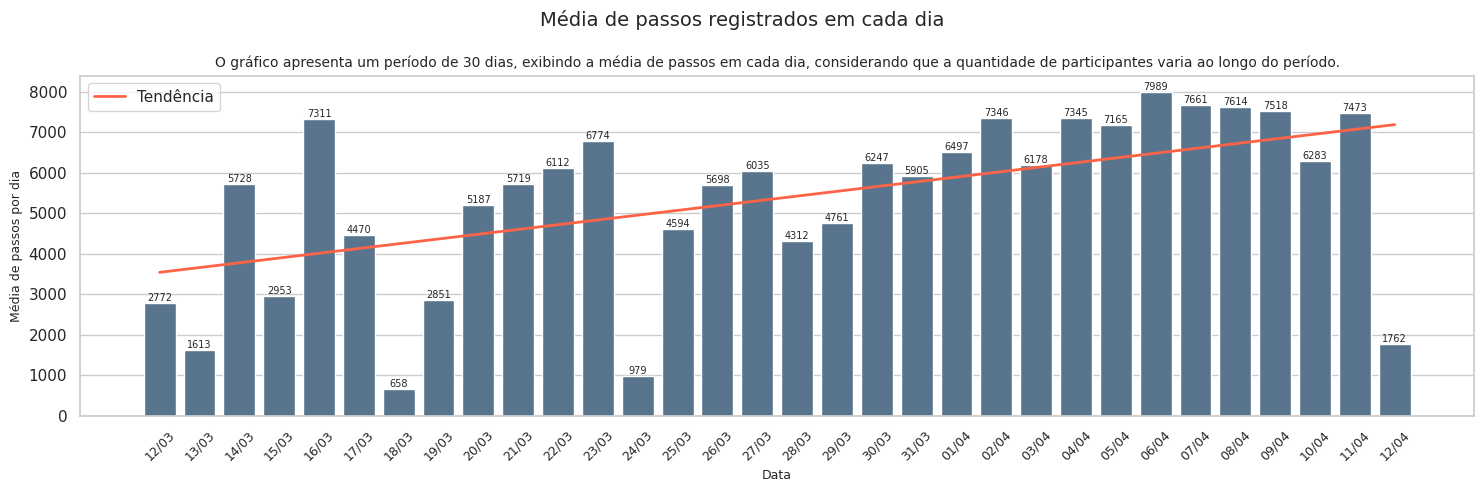

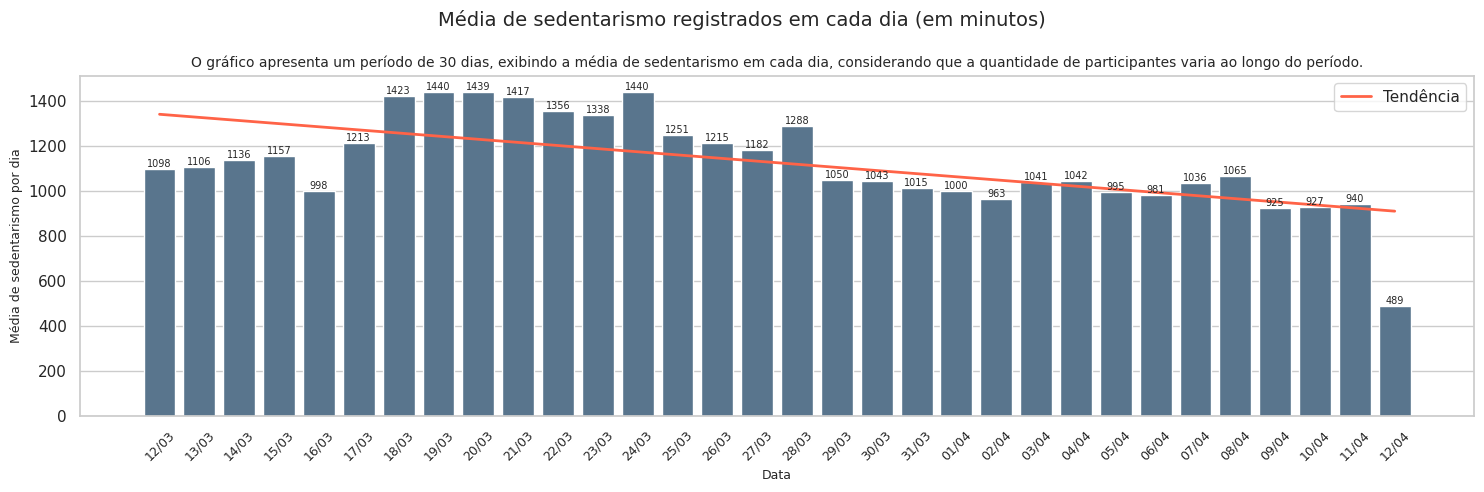

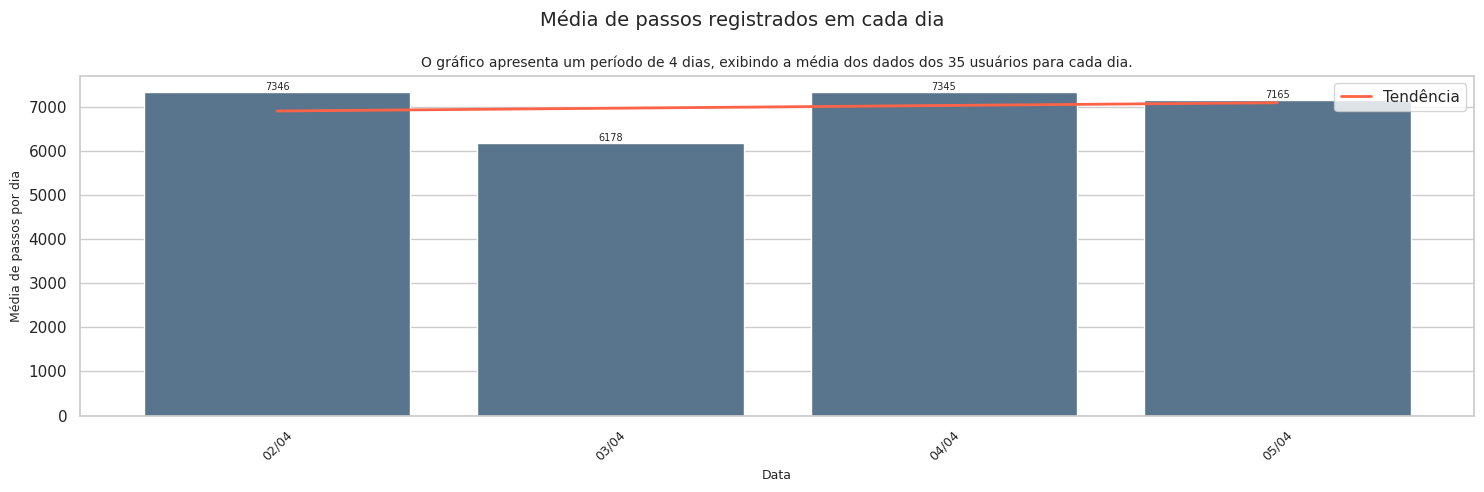

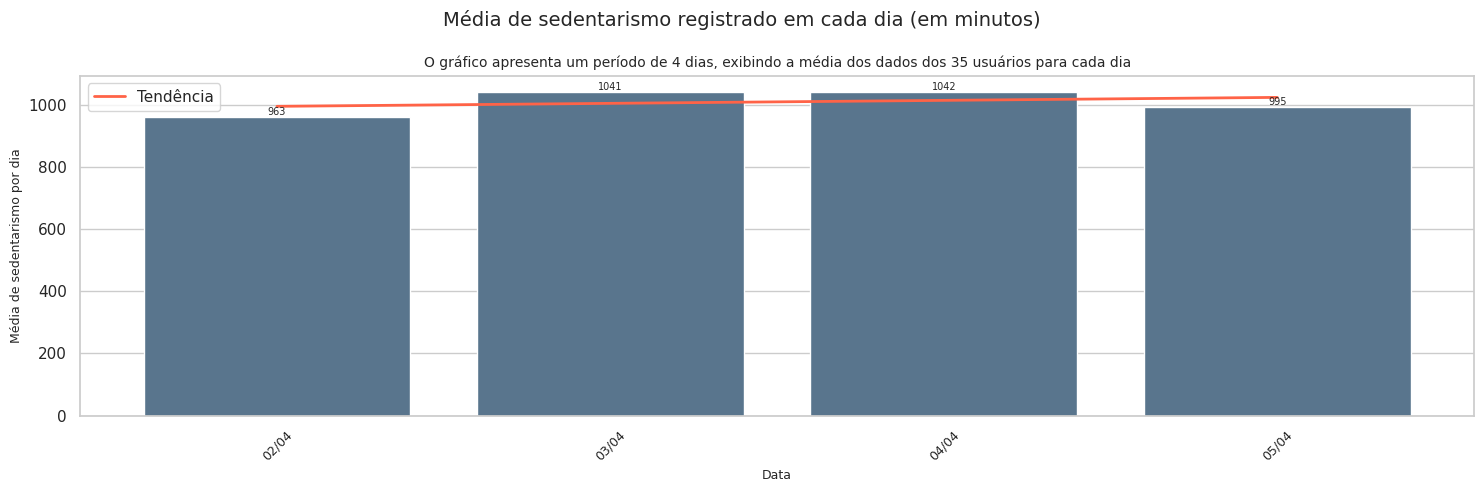

In [ ]:
# data, x, y, color, suptitle, title, ylabel, xlabel

# ANÁLISE GERAL

print('\n\n\n')

plot_bar_tendencia(
     media_geral,
    'ActivityDate',
    'TotalSteps',
    '#507696',
    'Média de passos registrados em cada dia',
    'O gráfico apresenta um período de 30 dias, exibindo a média de passos em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
    'Média de passos por dia',
    'Data'
    )

print('\n\n\n\n')

plot_bar_tendencia(
     media_geral_s,
    'ActivityDate',
    'SedentaryMinutes',
    '#507696',
    'Média de sedentarismo registrados em cada dia (em minutos)',
    'O gráfico apresenta um período de 30 dias, exibindo a média de sedentarismo em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
    'Média de sedentarismo por dia',
    'Data'
    )

print('\n\n\n')

# ANÁLISE ESPECÍFICA

plot_bar_tendencia(
     media_especifica,
    'ActivityDate',
    'TotalSteps',
    '#507696',
    'Média de passos registrados em cada dia',
    'O gráfico apresenta um período de 4 dias, exibindo a média dos dados dos 35 usuários para cada dia.',
    'Média de passos por dia',
    'Data'
    )

print('\n\n\n')

plot_bar_tendencia(
     media_especifica_s,
    'ActivityDate',
    'SedentaryMinutes',
    '#507696',
    'Média de sedentarismo registrado em cada dia (em minutos)',
    'O gráfico apresenta um período de 4 dias, exibindo a média dos dados dos 35 usuários para cada dia',
    'Média de sedentarismo por dia',
    'Data'
    )

#### 3.1.2 **(Abril/Maio) de 2016**

💡 **Descobertas relevantes**

- Assim como no período anterior, os dados apresentaram incompletude ao longo do período analisado, uma vez que, neste caso, nenhum dos períodos teve registros dos 35 usuários. No entanto, a variação na participação é menos expressiva em comparação ao período anterior, cada dia conta com registros de 21 a 33 usuários, uma amplitude consideravelmente menor.

- **Ponto de decisão:**  Diante disso, uma análise geral dos 30 dias foi considerada a abordagem mais adequada para este conjunto de dados.


---

✔️ **CONCLUSÃO**:

- A média diária de passos por usuário neste período é de 7.519 passos.
  
- Analisando cada dia entre final de abril e o final de maio, é possível notar a predominância de uma média que varia entre 6 mil a 8 mil passos diários: comportamento levemente maior em relação ao período anterior analisado.

- No que diz respeito ao sedentarismo, a média geral é de 999 minutos por usuário ao dia, o que equivale aproximadamente 17 horas: mais da metade do dia em estado sedentário.

##### 🔎 **Métricas/Cálculos**

1. Quantidade de registros por data;
2. Média de passos (geral e diária);
3. Média de sedentarismo (geral e diária);
4. Quantidade de pessoas que tiveram pelo menos um dia sedentário.

In [ ]:
# Quantidade de registros por data
registros_todos_ids_2 = todos_arquivos['dailyActivity_2'].groupby('ActivityDate').size()
print(f'1) Quantidade de registros por data:\n\n {registros_todos_ids_2}\n\n')


# MÉDIA GERAL DAS INFORMAÇÕES
media_30_dias_passos_2 = todos_arquivos['dailyActivity_2'].groupby('Id')['TotalSteps'].mean().mean()
media_30_dias_sedentarismo_2 = todos_arquivos['dailyActivity_2'].groupby('Id')['SedentaryMinutes'].mean().mean()
print(f'2) Média de passos por usuário: {media_30_dias_passos_2:.0f}')
print(f'3) Média de sedentarismo (min) por usuário: {media_30_dias_sedentarismo_2:.0f}')


# Média de passos registrados em cada dia
media_geral_2 = todos_arquivos['dailyActivity_2'].groupby('ActivityDate')['TotalSteps'].mean().reset_index()

# Média de sedentarismo registrados em cada dia
media_geral_s_2 = todos_arquivos['dailyActivity_2'].groupby('ActivityDate')['SedentaryMinutes'].mean().reset_index()

# Quantidade de pessoas que passam mais da metade do dia em estado sedentário (mais de 12 horas - 720 minutos)
sedentarismo_maior_12 = todos_arquivos['dailyActivity_2'][todos_arquivos['dailyActivity_2']['SedentaryMinutes'] > 720]
print(f'4) Quantidade de pessoas que forneceram seus dados no total: {todos_arquivos['dailyActivity_2']['Id'].nunique()}')
print(f'5) Quantidade de pessoas que tiveram pelo menos um dia sedentário: {sedentarismo_maior_12['Id'].nunique()}')

1) Quantidade de registros por data:

 ActivityDate
2016-04-12    33
2016-04-13    33
2016-04-14    33
2016-04-15    33
2016-04-16    32
2016-04-17    32
2016-04-18    32
2016-04-19    32
2016-04-20    32
2016-04-21    32
2016-04-22    32
2016-04-23    32
2016-04-24    32
2016-04-25    32
2016-04-26    32
2016-04-27    32
2016-04-28    32
2016-04-29    32
2016-04-30    31
2016-05-01    30
2016-05-02    29
2016-05-03    29
2016-05-04    29
2016-05-05    29
2016-05-06    29
2016-05-07    29
2016-05-08    27
2016-05-09    27
2016-05-10    26
2016-05-11    24
2016-05-12    21
dtype: int64


2) Média de passos por usuário: 7519
3) Média de sedentarismo (min) por usuário: 999
4) Quantidade de pessoas que forneceram seus dados no total: 33
5) Quantidade de pessoas que tiveram pelo menos um dia sedentário: 33


##### 📊 **Gráficos**

- Média de passos registrados em cada dia;
- Média de sedentarismo registrado em cada dia.

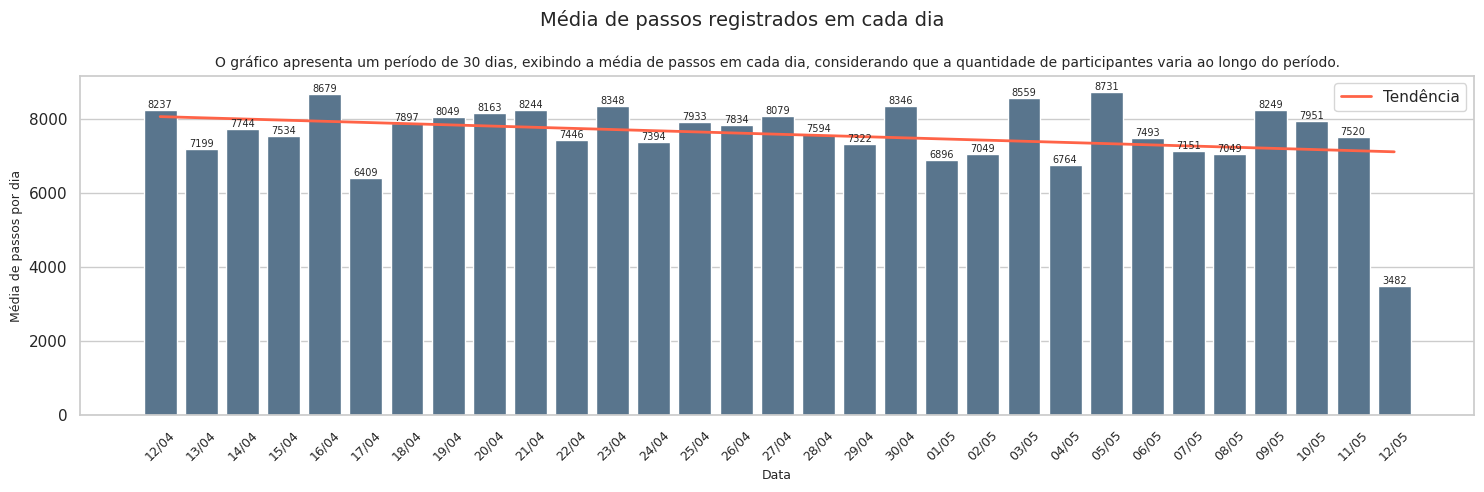

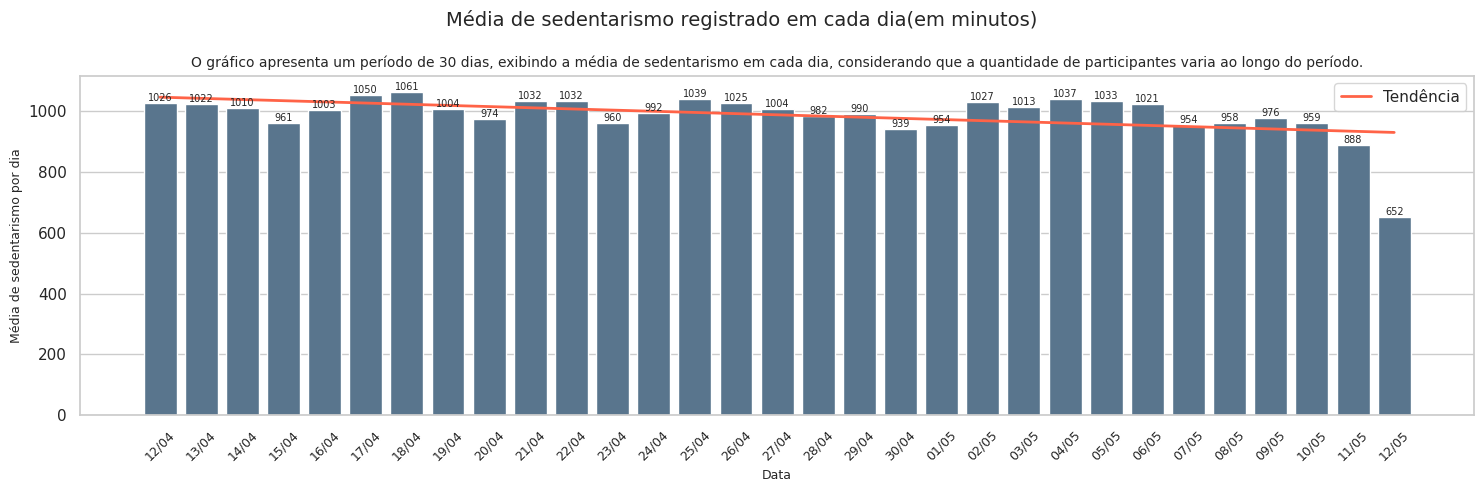

In [ ]:
# data, x, y, color, suptitle, title, ylabel, xlabel

print('\n\n\n\n')

plot_bar_tendencia(
     media_geral_2,
    'ActivityDate',
    'TotalSteps',
    '#507696',
    'Média de passos registrados em cada dia',
    'O gráfico apresenta um período de 30 dias, exibindo a média de passos em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
    'Média de passos por dia',
    'Data'
    )

print('\n\n\n\n')

plot_bar_tendencia(
     media_geral_s_2,
    'ActivityDate',
    'SedentaryMinutes',
    '#507696',
    'Média de sedentarismo registrado em cada dia(em minutos)',
    'O gráfico apresenta um período de 30 dias, exibindo a média de sedentarismo em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
    'Média de sedentarismo por dia',
    'Data'
    )

### 3.2 Sono diário dos usuários (Abril/Maio de 2016)

["Adultos de 18 a 60 anos devem ter 7 ou mais horas de descanso por noite; indivíduos de 61 a 64 anos, entre 7 e 9 horas; e pessoas com mais de 65 anos de idade, cerca de 7 ou 8 horas, segundo os CDC."](https://www.nationalgeographicbrasil.com/ciencia/2023/04/quantas-horas-de-sono-por-dia-sao-ideais-para-cada-idade)

Nesta seção, é apresentada uma análise dos padrões de sono dos participantes, com base nos dados coletados por dispositivos inteligentes.

A análise contempla os seguintes indicadores:

- **Média de sono por cada dia e por usuário** (em minutos): tempo médio efetivamente dormido.
- **Média do tempo total na cama por cada dia e por usuário** (em minutos): duração média em que o usuário permaneceu na cama.
- **Percentual de eficiência do sono por usuário**: proporção entre a média de tempo dormido e a média de tempo na cama, indicando a qualidade do sono.

---

💡 **Descobertas relevantes**

- Esta métrica possui o mesmo problema identificado durante a análise das métricas anteriores: incompletude dos dados. Entretando, não há divergências exorbitantes, visto que a quantidade de usuários que participou diariamente varia entre 11 a 17 participantes, tendo apenas um único caso com 8 participantes. Sendo assim, nenhuma data consta a presença dos 35 usuários.

-  **Ponto de decisão:**  Diante disso, uma análise geral dos 30 dias foi considerada a abordagem mais adequada para este conjunto de dados.

---

✔️ **CONCLUSÃO**:

- Os usuários possuem uma média de sono de 377 minutos por noite, o que equivale 6 horas e 17 minutos.


- Os usuários possuem uma média de 420 minutos de tempo total na cama por noite, sendo 7 horas.


- Ou seja, em média, a eficiência do sono é de aproximadamente 89,88%, considerando o tempo total em que a pessoa permanece deitada em relação ao tempo efetivamente dormindo. Embora a eficiência do sono esteja adequada, o tempo efetivo de sono ainda é um ponto de atenção, pois:


- Para adultos, é recomendado ter 7 horas ou mais de descanso por noite. Nesse contexto, a média observada está no limite inferior do recomendado, indicando atenção, já que ainda há pessoas que dormem menos de 7 horas por dia, o que pode ser prejudicial à saúde.


- Além disso, dos 24 usuários analisados, 23 já dormiram menos de 7 horas em pelo menos um dia, o que reforça que a insuficiência de sono não é um caso isolado, mas sim um comportamento recorrente entre os participantes.



#### 🔎 **Métricas/Cálculos**  

1. Quantidade de registros por data;
2. Média de sono (geral e diária);
3. Média do tempo total na cama (geral e diária);
4. Percentual de eficiência do sono;
5. Quantidade de pessoas que dormiram menos de 7 horas pelo menos uma vez.

In [ ]:
# Quantidade de registros por data
qtd_registros = todos_arquivos['sleepDay_2'].groupby('SleepDay')['Id'].size()
print(f'1) Quantidade de registros por data:\n\n {qtd_registros}\n\n')

# Média de sono registrado em cada dia (em minutos)
media_sono_dia = todos_arquivos['sleepDay_2'].groupby('SleepDay')['TotalMinutesAsleep'].mean().reset_index()

# Média de sono registrado em cada dia (em minutos)
media_cama_dia = todos_arquivos['sleepDay_2'].groupby('SleepDay')['TotalTimeInBed'].mean().reset_index()

# Média geral das informações
media_geral_sono = todos_arquivos['sleepDay_2'].groupby('Id')['TotalMinutesAsleep'].mean().mean()
media_geral_cama = todos_arquivos['sleepDay_2'].groupby('Id')['TotalTimeInBed'].mean().mean()
media_percentual_sono = (media_geral_sono / media_geral_cama) * 100
print(f'2) Média de sono por usuário (em minutos): {media_geral_sono:.0f}')
print(f'3) Média do tempo total na cama por usuário (em minutos): {media_geral_cama:.0f}')
print(f'4) Percentual de eficiência do sono por usuário: {media_percentual_sono:.2f}%\n')

# Quantidade de pessoas que dormiram menos de 7 horas
sono_menor_7 = todos_arquivos['sleepDay_2'][todos_arquivos['sleepDay_2']['TotalMinutesAsleep'] < 420]
print(f'5) Quantidade de pessoas que forneceram seus dados no total: {todos_arquivos['sleepDay_2']['Id'].nunique()}')
print(f'6) Quantidade de pessoas que dormiram menos de 7 horas pelo menos uma vez: {sono_menor_7['Id'].nunique()}')

1) Quantidade de registros por data:

 SleepDay
2016-04-12    13
2016-04-13    14
2016-04-14    13
2016-04-15    17
2016-04-16    14
2016-04-17    12
2016-04-18    10
2016-04-19    14
2016-04-20    15
2016-04-21    15
2016-04-22    13
2016-04-23    15
2016-04-24    13
2016-04-25    12
2016-04-26    14
2016-04-27    14
2016-04-28    16
2016-04-29    15
2016-04-30    15
2016-05-01    16
2016-05-02    13
2016-05-03    12
2016-05-04    12
2016-05-05    12
2016-05-06    12
2016-05-07    13
2016-05-08    14
2016-05-09    11
2016-05-10    12
2016-05-11    11
2016-05-12     8
Name: Id, dtype: int64


2) Média de sono por usuário (em minutos): 377
3) Média do tempo total na cama por usuário (em minutos): 420
4) Percentual de eficiência do sono por usuário: 89.88%

5) Quantidade de pessoas que forneceram seus dados no total: 24
6) Quantidade de pessoas que dormiram menos de 7 horas pelo menos uma vez: 23


#### 📊 **Gráficos**

1. Média de sono registrado em cada dia (em minutos);
2. Média do tempo total na cama registrado em cada dia (em minutos).

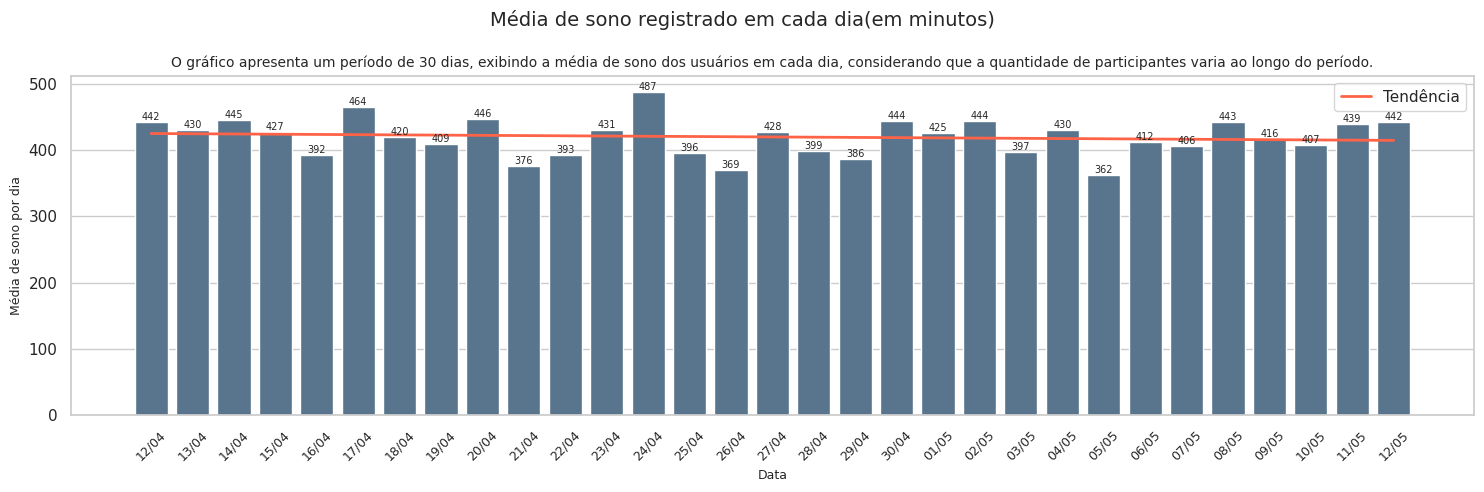

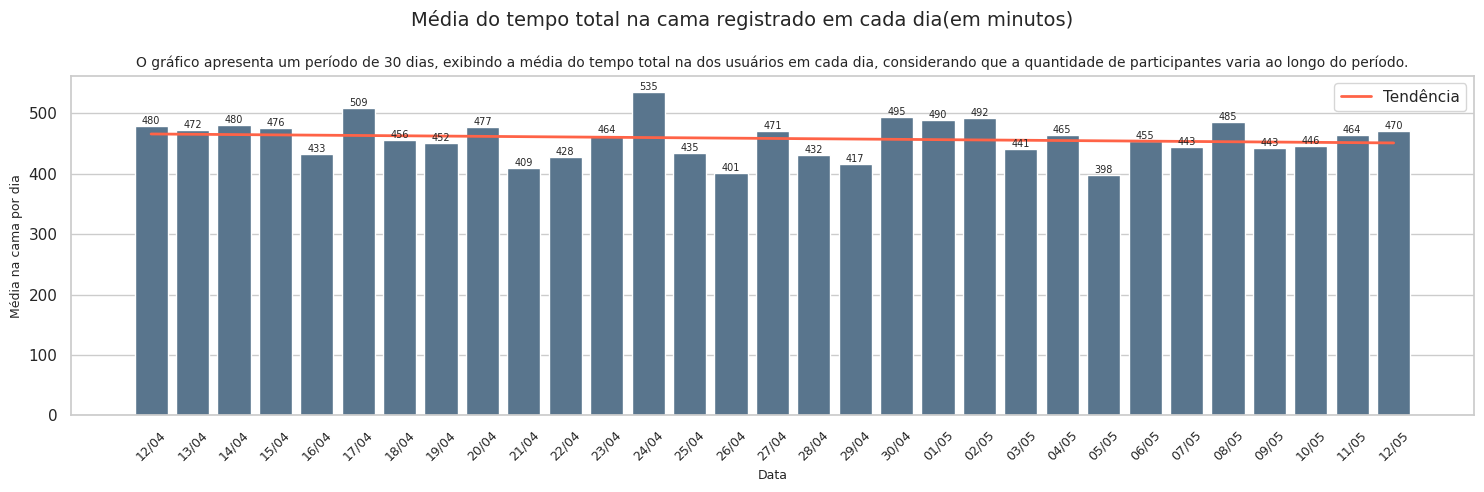

In [ ]:
# data, x, y, color, suptitle, title, ylabel, xlabel
plot_bar_tendencia(
                    media_sono_dia,
                   'SleepDay',
                   'TotalMinutesAsleep',
                   '#507696',
                   'Média de sono registrado em cada dia(em minutos)',
                   'O gráfico apresenta um período de 30 dias, exibindo a média de sono dos usuários em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
                   'Média de sono por dia',
                   'Data')

plot_bar_tendencia(
                    media_cama_dia,
                    'SleepDay',
                    'TotalTimeInBed',
                    '#507696',
                    'Média do tempo total na cama registrado em cada dia(em minutos)',
                    'O gráfico apresenta um período de 30 dias, exibindo a média do tempo total na dos usuários em cada dia, considerando que a quantidade de participantes varia ao longo do período.',
                    'Média na cama por dia',
                    'Data'
)

## 4. **Análise explanatória: Conclusões acionáveis e Estratégias de marketing**

<br>

A análise exploratória dos dados de atividade física, sedentarismo e sono dos usuários Fitbit em 2016 permitiu identificar padrões comportamentais cruciais para o direcionamento de estratégias de marketing da Bellabeat. Os resultados evidenciam que, apesar do monitoramento ativo da saúde, prevalecem hábitos que podem comprometer o bem-estar dos usuários, especificamente a alta incidência de sedentarismo e a instabilidade na qualidade do sono. Tais constatações reforçam a oportunidade de desenvolver intervenções focadas na melhoria da rotina de sono e na redução do tempo de inatividade.

Ademais, acrescento nesta seção outras visualizações que complementam os insights obtidos.

---

>**Como essas tendências podem se aplicar aos clientes da Bellabeat? E como essas tendências podem ajudar a influenciar a estratégia de marketing da Bellabeat?**
>
>No contexto das clientes da Bellabeat, o produto que melhor atenderia ao perfil de usuárias ativas e, principalmente, sedentárias é o Time: um relógio de bem-estar que une o design atemporal de um relógio clássico à tecnologia inteligente de monitoramento de atividade física, sono e estresse. Integrado ao aplicativo Bellabeat, o Time fornece insights personalizados sobre o bem-estar diário, funcionando não apenas como um rastreador, mas como um meio eficaz de estabelecer e acompanhar metas individuais.
>
>Diante disso, uma das estratégias de marketing sugeridas é o desenvolvimento de um infográfico curto, direto e visualmente atrativo, voltado ao público feminino, para veiculação nas principais plataformas digitais (Google, Facebook, Instagram e X). O material deverá destacar a importância do monitoramento da saúde e apresentar ao menos três benefícios concretos do relógio Time, como o controle de metas individuais, o acompanhamento de indicadores de risco e os alertas para situações fora do padrão habitual, a serem validados em conjunto com a equipe executiva da Bellabeat.
>
>O conteúdo deverá ser segmentado para dois perfis distintos:
>
>- Mulheres sedentárias e com problemas de sono: com foco no incentivo à mudança de hábitos, evidenciando a relação entre sedentarismo, sono insuficiente e o risco de desenvolvimento de doenças crônicas;
>  
>- Mulheres ativas: com foco na manutenção e evolução dos resultados, destacando como o produto pode apoiá-las no cumprimento de suas metas de movimento diário e como a assinatura Bellabeat pode oferecer suporte personalizado para questões de saúde e objetivos individuais.
>
>Nesse sentido, a empresa pode reforçar em seus canais de comunicação que, com o monitoramento contínuo proporcionado pelo relógio, as usuárias passam a ter maior controle sobre sua saúde e rotina. O dispositivo pode estabelecer metas personalizadas de sono, recomendando ao menos 7 horas por noite, ajustadas conforme a faixa etária, ao mesmo tempo incentivar a prática de atividades físicas, como caminhadas e esportes, contribuindo para o aumento gradual dos passos diários. À medida que o nível de movimento cresce, o sedentarismo tende a diminuir e a qualidade do sono tende a melhorar; para reforçar esse processo, o relógio pode emitir alertas sempre que o tempo de inatividade ao longo do dia for considerado elevado.

### 📊 **Gráficos**: Tendências no uso de dispositivos inteligentes

#### **1. Correlações:**

>**Existe correlação entre o tempo de sedentarismo e a quantidade de passos?**
>  
>Sim, é evidente que, quanto menos passos uma pessoa costuma dar por dia, mais sedentária ela tende a ser, o que caracteriza uma correlação negativa (-0.28). Entretanto, não se trata de uma relação forte, pois há muitos pontos de dados elevados e dispersos.



>**Existe correlação entre o tempo de sedentarismo e as horas de sono?**
>
>Sim, é evidente que, quanto mais tempo de sedentarismo o usuário costuma apresentar, menos tempo de sono efetivo ele tem, o que caracteriza uma correlação negativa moderada (-0.60).


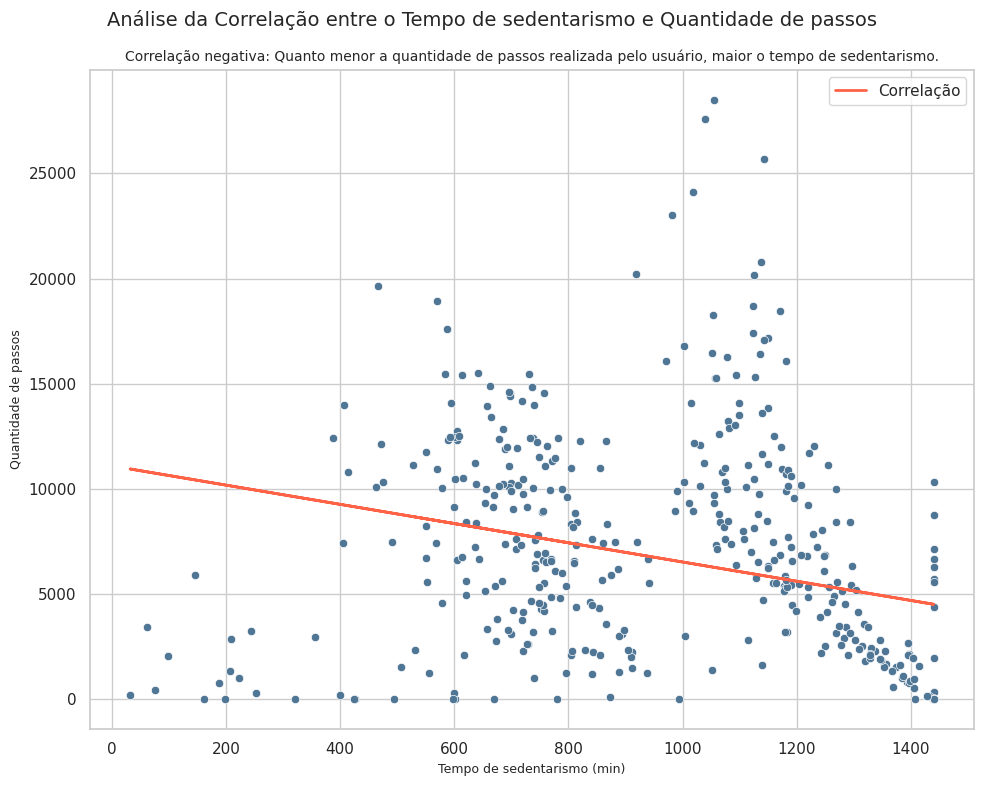

Índice de correlação: -0.28525770549310286


In [ ]:
# Análise da correlação entre o tempo de sedentarismo e quantidade de passos

data = todos_arquivos['dailyActivity_1']

dispersao(data,
          'SedentaryMinutes',
          'TotalSteps',
          'Análise da Correlação entre o Tempo de sedentarismo e Quantidade de passos',
          'Correlação negativa: Quanto menor a quantidade de passos realizada pelo usuário, maior o tempo de sedentarismo.',
          'Quantidade de passos',
          'Tempo de sedentarismo (min)')  # Correlação negativa fraca

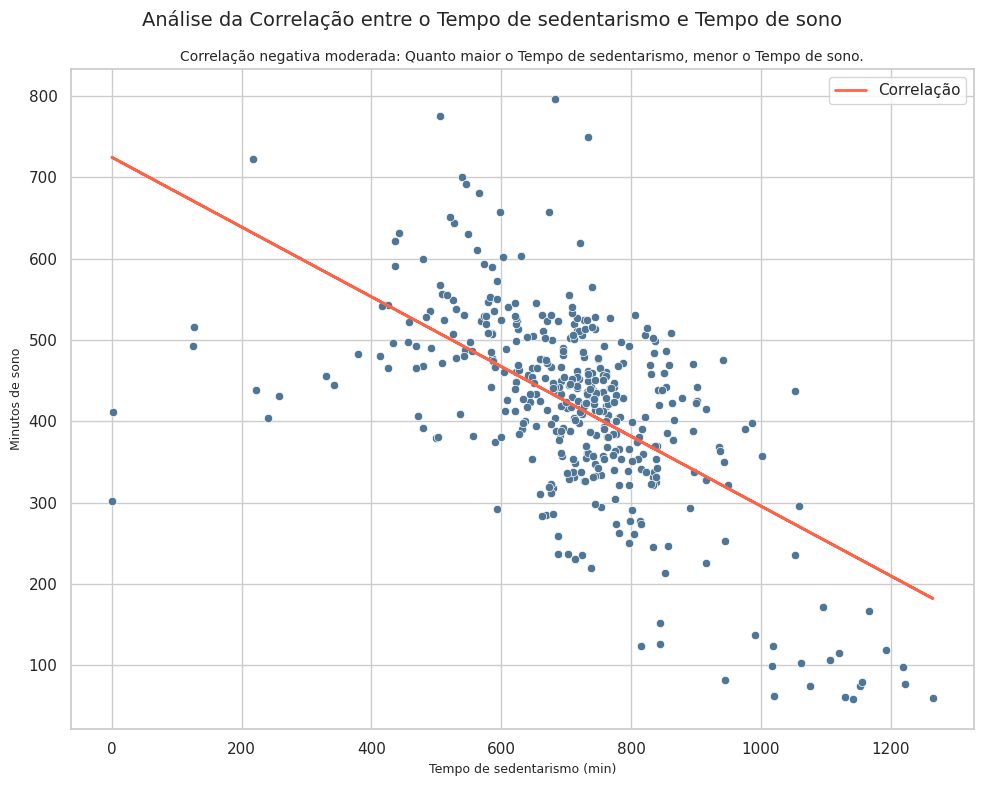

Índice de correlação: -0.6010731396971011


In [ ]:
# Análise da correlação entre o tempo de sedentarismo e tempo de sono

tabelas_unidas = todos_arquivos['dailyActivity_2'].merge(todos_arquivos['sleepDay_2'], left_on = ['Id', 'ActivityDate'], right_on = ['Id', 'SleepDay'], how = 'inner')

dispersao(tabelas_unidas,
          'SedentaryMinutes',
          'TotalMinutesAsleep',
          'Análise da Correlação entre o Tempo de sedentarismo e Tempo de sono',
          'Correlação negativa moderada: Quanto maior o Tempo de sedentarismo, menor o Tempo de sono.',
          'Minutos de sono',
          'Tempo de sedentarismo (min)')  # Correlação negativa moderada

#### **2. Atividade física**

> Os resultados indicam um padrão comportamental definido na prática de exercícios físicos pelos usuários. Observa-se que, ao realizar atividades de intensidade leve, os usuários permanecem ativos por períodos mais longos, distanciando-se do estado sedentário. Em contrapartida, há uma redução significativa no tempo dedicado a atividades de intensidade moderada a intensa, sugerindo uma preferência ou maior facilidade de manutenção em exercícios de menor esforço físico.

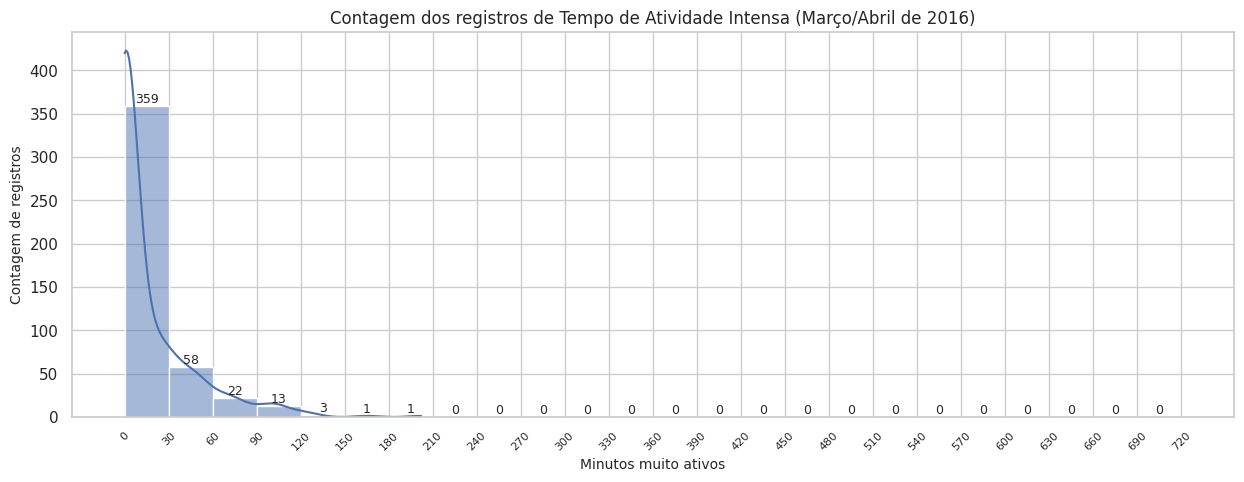

count    457.000000
mean      16.623632
std       28.919704
min        0.000000
25%        0.000000
50%        0.000000
75%       25.000000
max      202.000000
Name: VeryActiveMinutes, dtype: float64

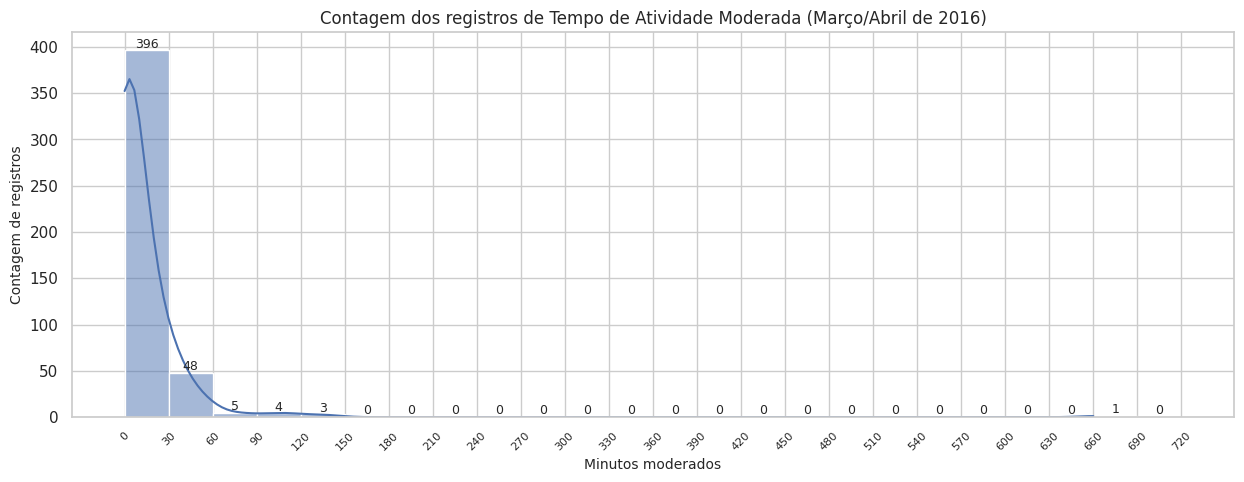

count    457.000000
mean      13.070022
std       36.208635
min        0.000000
25%        0.000000
50%        1.000000
75%       16.000000
max      660.000000
Name: FairlyActiveMinutes, dtype: float64

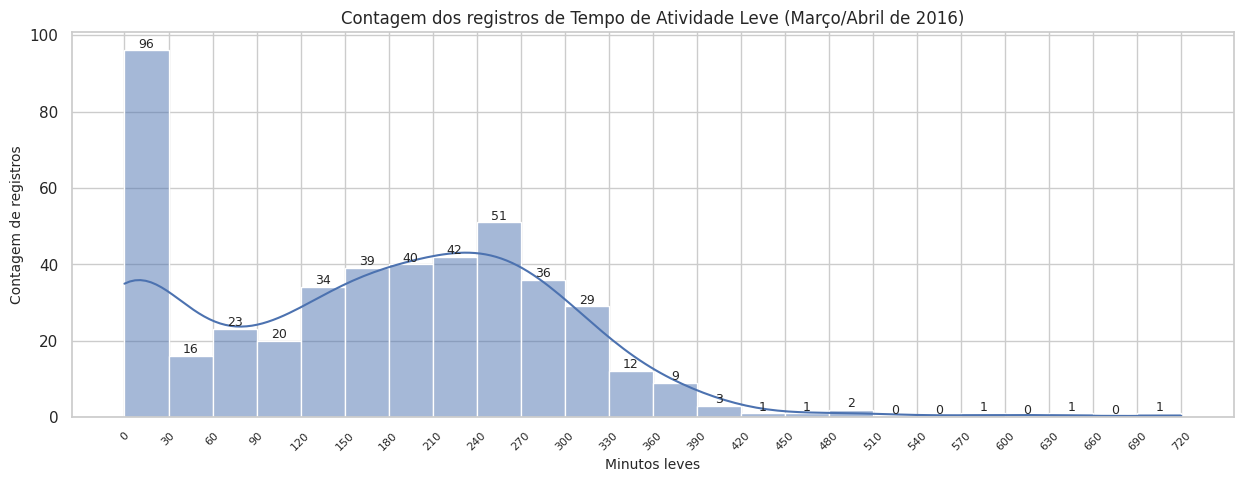

count    457.000000
mean     170.070022
std      122.205372
min        0.000000
25%       64.000000
50%      181.000000
75%      257.000000
max      720.000000
Name: LightlyActiveMinutes, dtype: float64

In [ ]:
intenso = todos_arquivos['dailyActivity_1']['VeryActiveMinutes']
moderado = todos_arquivos['dailyActivity_1']['FairlyActiveMinutes']
leve = todos_arquivos['dailyActivity_1']['LightlyActiveMinutes']


histograma(intenso,'Contagem dos registros de Tempo de Atividade Intensa (Março/Abril de 2016)', 'Contagem de registros', 'Minutos muito ativos')
print('\n\n\n')

histograma(moderado,'Contagem dos registros de Tempo de Atividade Moderada (Março/Abril de 2016)', 'Contagem de registros', 'Minutos moderados')
print('\n\n\n')

histograma(leve,'Contagem dos registros de Tempo de Atividade Leve (Março/Abril de 2016)', 'Contagem de registros', 'Minutos leves')


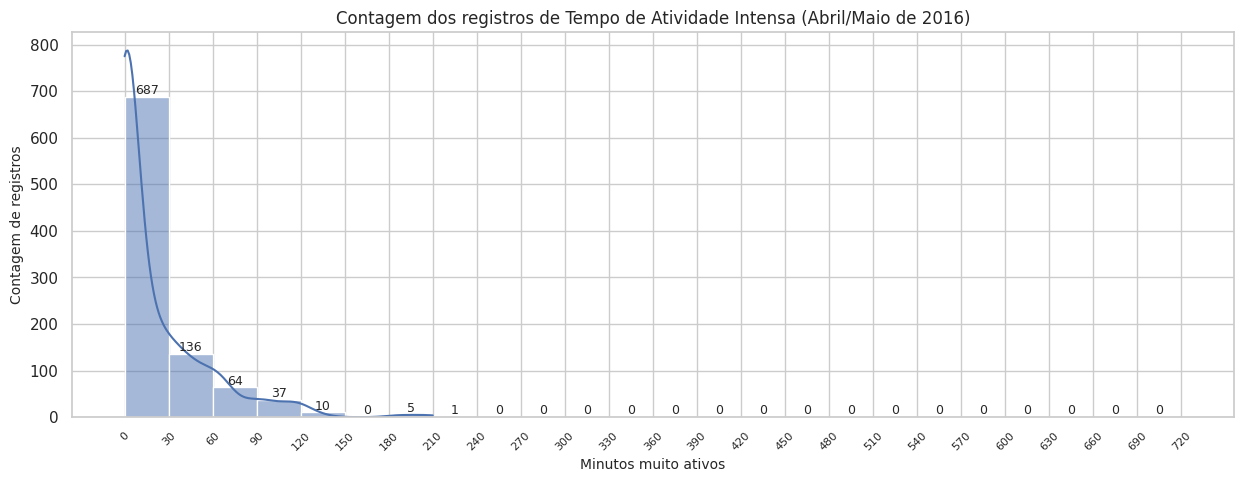

count    940.000000
mean      21.164894
std       32.844803
min        0.000000
25%        0.000000
50%        4.000000
75%       32.000000
max      210.000000
Name: VeryActiveMinutes, dtype: float64

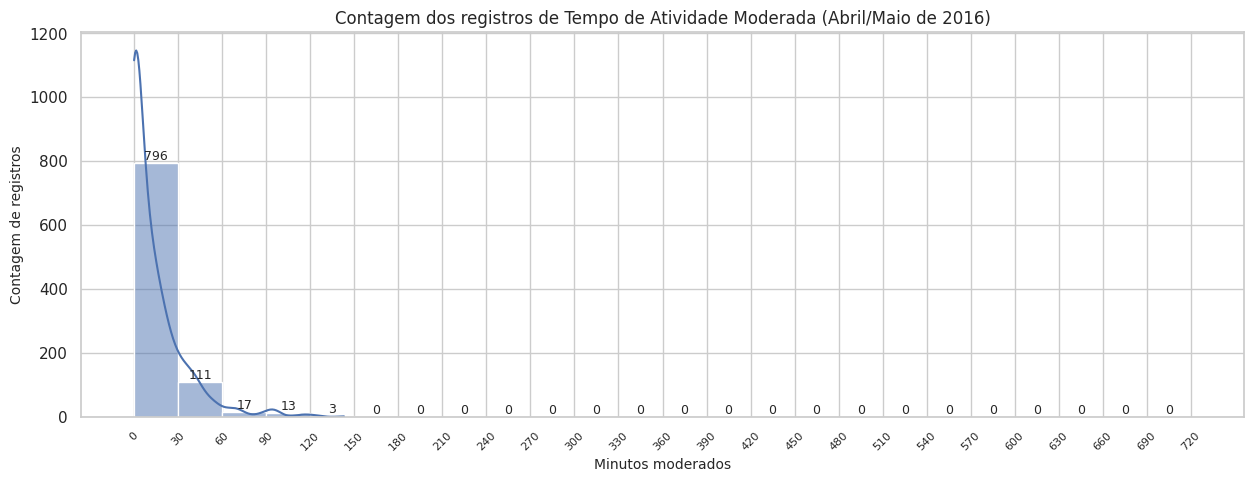

count    940.000000
mean      13.564894
std       19.987404
min        0.000000
25%        0.000000
50%        6.000000
75%       19.000000
max      143.000000
Name: FairlyActiveMinutes, dtype: float64

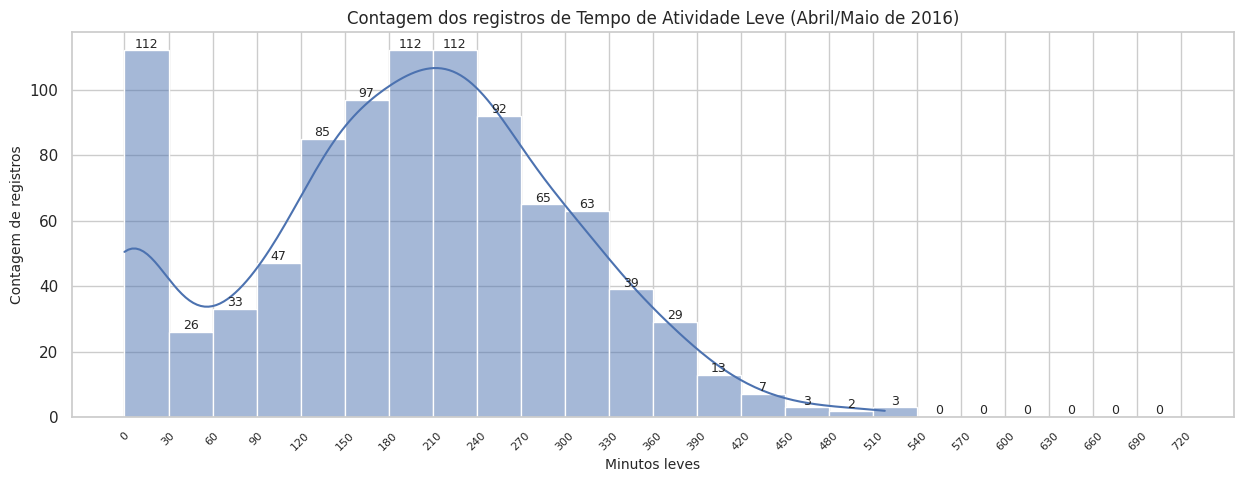

count    940.000000
mean     192.812766
std      109.174700
min        0.000000
25%      127.000000
50%      199.000000
75%      264.000000
max      518.000000
Name: LightlyActiveMinutes, dtype: float64

In [ ]:
intenso_2 = todos_arquivos['dailyActivity_2']['VeryActiveMinutes']
moderado_2 = todos_arquivos['dailyActivity_2']['FairlyActiveMinutes']
leve_2 = todos_arquivos['dailyActivity_2']['LightlyActiveMinutes']


histograma(intenso_2,'Contagem dos registros de Tempo de Atividade Intensa (Abril/Maio de 2016)', 'Contagem de registros', 'Minutos muito ativos')
print('\n\n\n')

histograma(moderado_2,'Contagem dos registros de Tempo de Atividade Moderada (Abril/Maio de 2016)', 'Contagem de registros', 'Minutos moderados')
print('\n\n\n')

histograma(leve_2,'Contagem dos registros de Tempo de Atividade Leve (Abril/Maio de 2016)', 'Contagem de registros', 'Minutos leves')

#### **3. Sedentarismo**


> - O tempo médio de sedentarismo ultrapassa a metade do dia, o que também representa um fator de risco à saúde.
>   
> - Observa-se ainda que 100% dos usuários, tanto no período de março a abril quanto de abril a maio, tiveram dias em que permaneceram mais de 12 horas em estado sedentário.




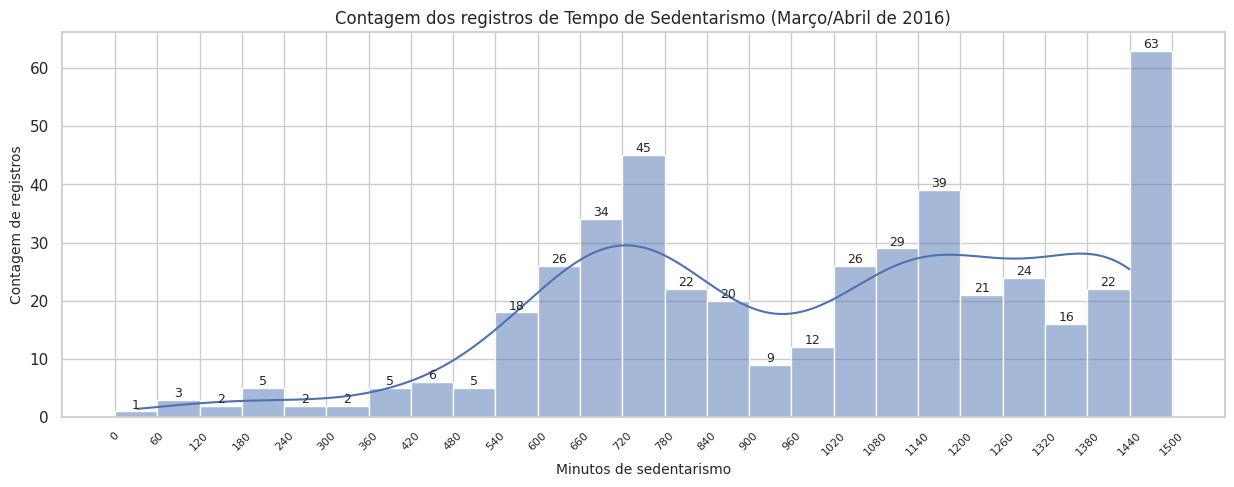

count     457.000000
mean      995.282276
std       337.021404
min        32.000000
25%       728.000000
50%      1057.000000
75%      1285.000000
max      1440.000000
Name: SedentaryMinutes, dtype: float64

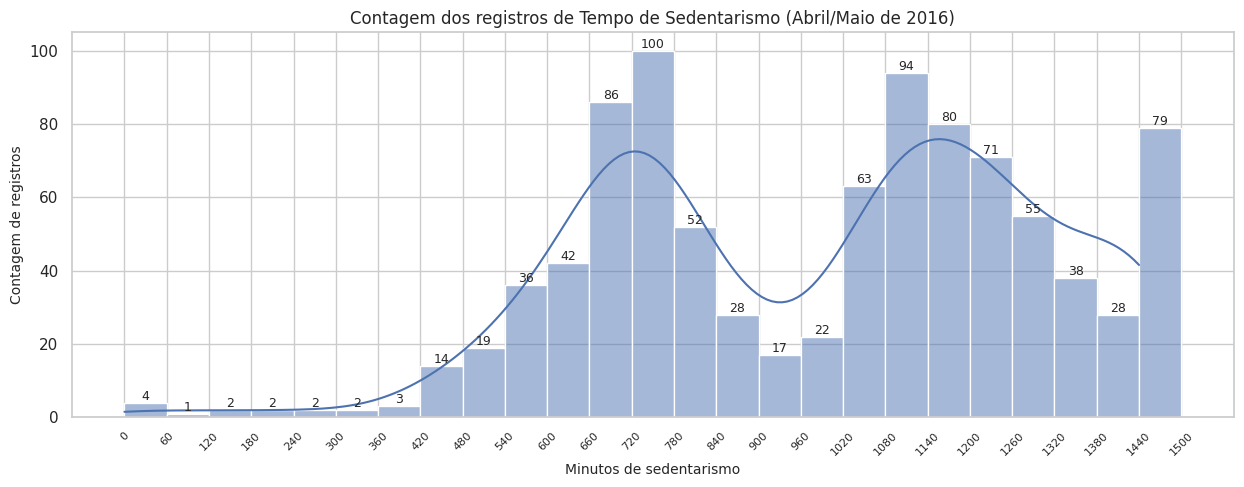

count     940.000000
mean      991.210638
std       301.267437
min         0.000000
25%       729.750000
50%      1057.500000
75%      1229.500000
max      1440.000000
Name: SedentaryMinutes, dtype: float64

In [ ]:
sedentarismo_1 = todos_arquivos['dailyActivity_1']['SedentaryMinutes']

histograma(sedentarismo_1,'Contagem dos registros de Tempo de Sedentarismo (Março/Abril de 2016)', 'Contagem de registros', 'Minutos de sedentarismo')

print('\n\n\n')

sedentarismo_2 = todos_arquivos['dailyActivity_2']['SedentaryMinutes']

histograma(sedentarismo_2,'Contagem dos registros de Tempo de Sedentarismo (Abril/Maio de 2016)', 'Contagem de registros', 'Minutos de sedentarismo')

print('\n\n\n')

#### **4. Sono efetivo**

> - Aproximadamente 95,8% dos usuários (23 de 24) apresentaram, em algum momento, menos de 7 horas de sono, que é o tempo mínimo recomendado para adultos.
>
> - Os usuários dormem em média **6 horas e 17 minutos** por noite registrada.
>
> - A maior quantidade de registros de sono efetivo é entre 7 horas a 8 horas, com total de 113 registros.

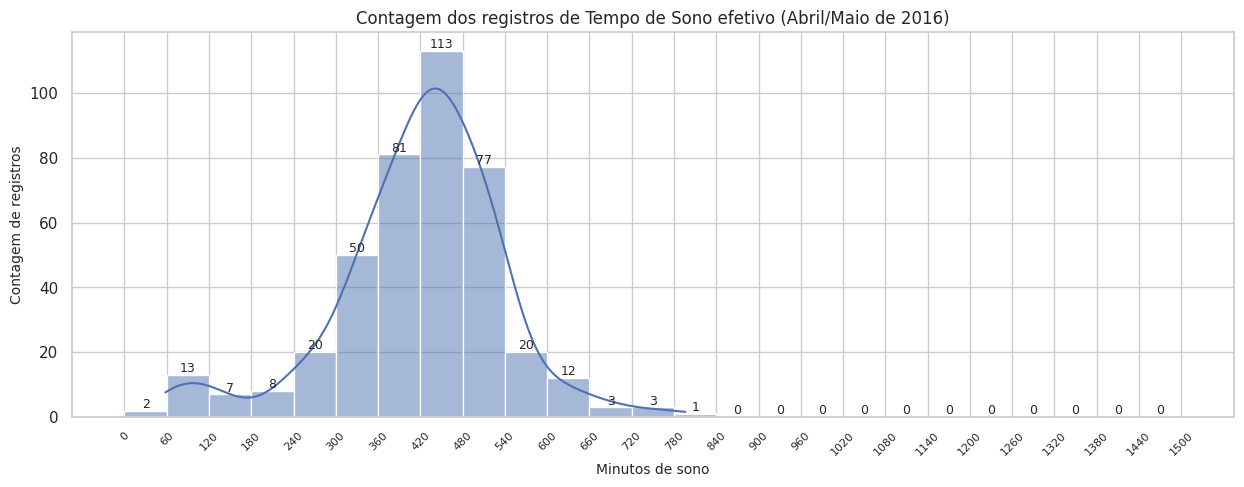

count    410.000000
mean     419.173171
std      118.635918
min       58.000000
25%      361.000000
50%      432.500000
75%      490.000000
max      796.000000
Name: TotalMinutesAsleep, dtype: float64

In [ ]:
sono = todos_arquivos['sleepDay_2']['TotalMinutesAsleep']

histograma(sono,'Contagem dos registros de Tempo de Sono efetivo (Abril/Maio de 2016)', 'Contagem de registros', 'Minutos de sono')

print('\n\n\n')